<a href="https://colab.research.google.com/github/Prakat-star/FDS/blob/main/lab3_bct024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

creating population distribution and plotting population distribution and sampling distribution

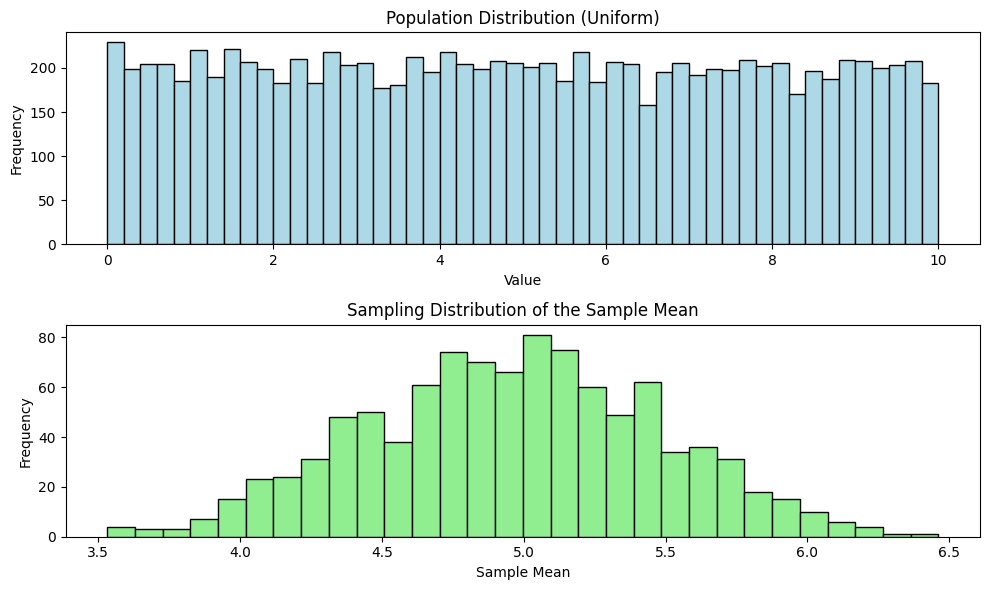

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
populationsize = 10000
populationdata = np.random.uniform(low=0, high=10, size=populationsize)

def simulate_clt(populationdata, samplesize, numsamples):
  samplemeans = []
  for _ in range(numsamples):
    sample = np.random.choice(populationdata, size=samplesize, replace=False)
    samplemeans.append(np.mean(sample))
  return samplemeans

samplesize = 30
numsamples = 1000
samplemeans = simulate_clt(populationdata, samplesize, numsamples)

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.hist(populationdata, bins=50, color='lightblue', edgecolor='black')
plt.title("Population Distribution (Uniform)")
plt.xlabel('Value')
plt.ylabel("Frequency")

plt.subplot(2,1,2)
plt.hist(samplemeans, bins=30, color='lightgreen', edgecolor='black')
plt.title("Sampling Distribution of the Sample Mean")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


plotting population mean and sample mean (exponential)

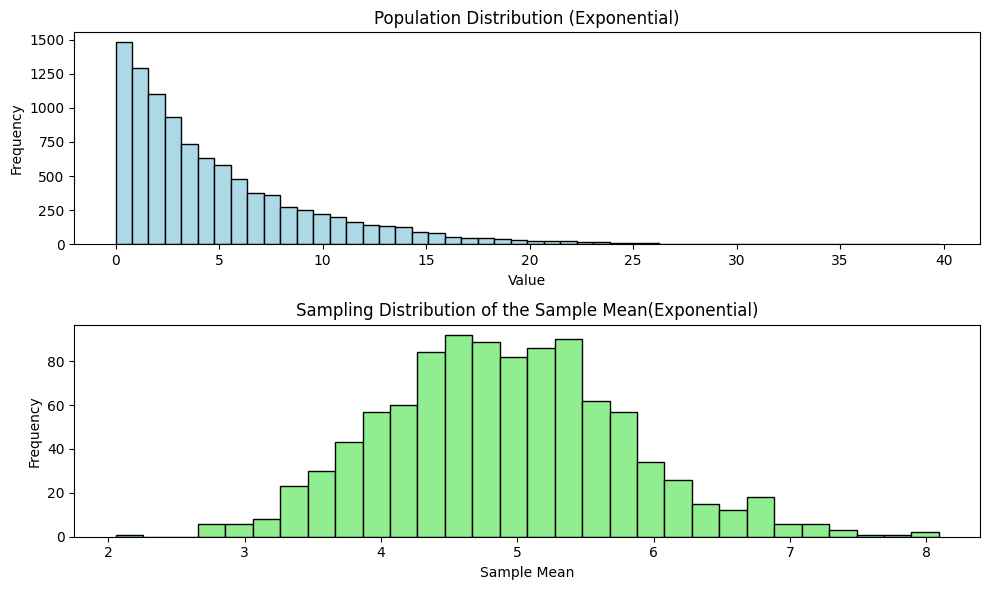

In [ ]:
populationdataexp=np.random.exponential(scale=5,size=10000)
samplemeansexp=simulate_clt(populationdataexp,samplesize=30,numsamples=1000)
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.hist(populationdataexp,bins=50,color='lightblue',edgecolor='black')
plt.title("Population Distribution (Exponential)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.subplot(2,1,2)
plt.hist(samplemeansexp,bins=30,color='lightgreen',edgecolor='black')
plt.title("Sampling Distribution of the Sample Mean(Exponential)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


plotting population and sampling distribution(binomial)

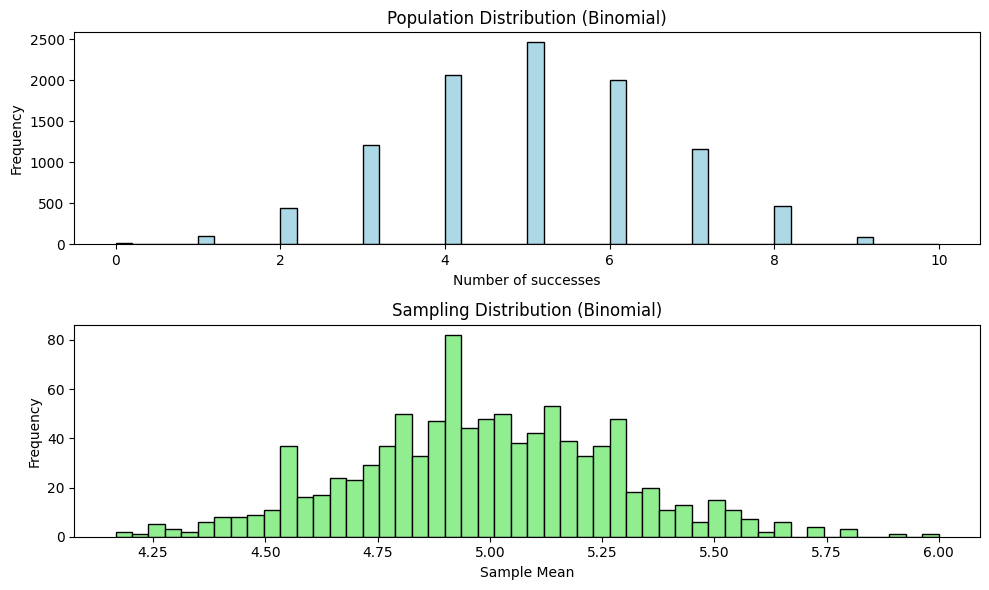

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_clt(populationdata, samplesize, numsamples):
    samplemeans = []
    for i in range(numsamples):
        sample = np.random.choice(populationdata, size=samplesize, replace=True)
        samplemeans.append(np.mean(sample))
    return samplemeans
populationdatabinom = np.random.binomial(n=10, p=0.5, size=10000)
samplemeansbinom = simulate_clt(populationdatabinom, samplesize=30, numsamples=1000)

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.hist(populationdatabinom, bins=50, color='lightblue', edgecolor='black')
plt.title("Population Distribution (Binomial)")
plt.xlabel("Number of successes")
plt.ylabel("Frequency")

plt.subplot(2,1,2)
plt.hist(samplemeansbinom, bins=50, color='lightgreen', edgecolor='black')
plt.title("Sampling Distribution (Binomial)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



plotting distribution of sample for different sample sizes

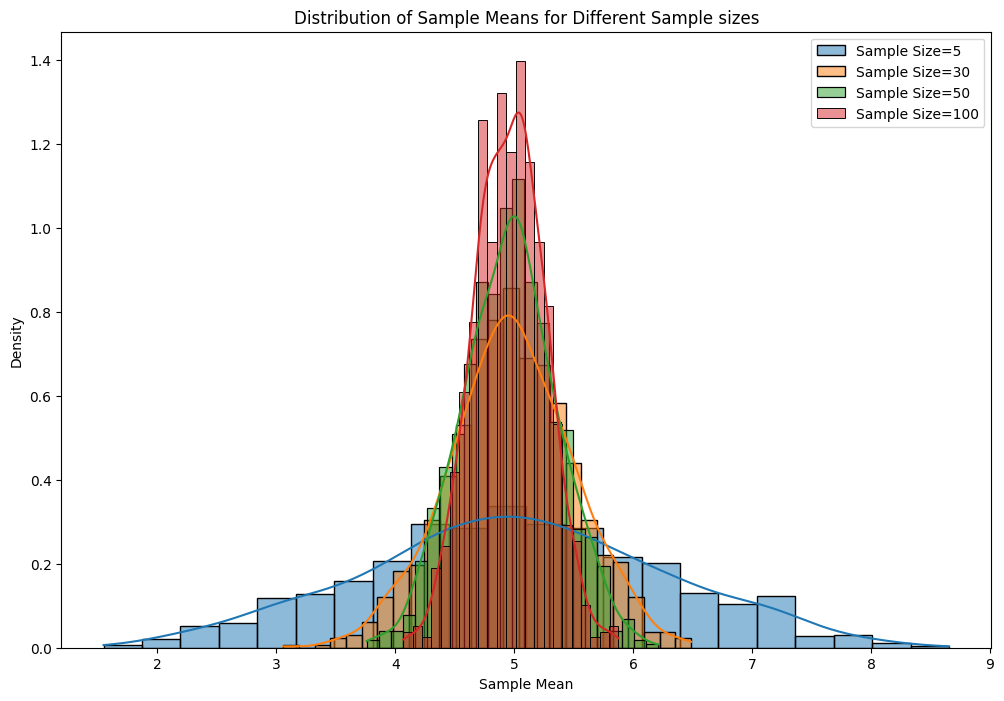

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
population=np.random.uniform(0,10,10000)
samplesizes=[5,30,50,100]
numsamples=1000
samplemeans={size:[]for size in samplesizes}
for size in samplesizes:
  for _ in range(numsamples):
    sample=np.random.choice(population,size=size,replace=False)
    samplemeans[size].append(np.mean(sample))
plt.figure(figsize=(12,8))
for size in samplesizes:
  sns.histplot(samplemeans[size],kde=True,label=f'Sample Size={size}',stat='density')
plt.title("Distribution of Sample Means for Different Sample sizes")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()
plt.show()



plotting simulated sample means and theoretical normal distribution

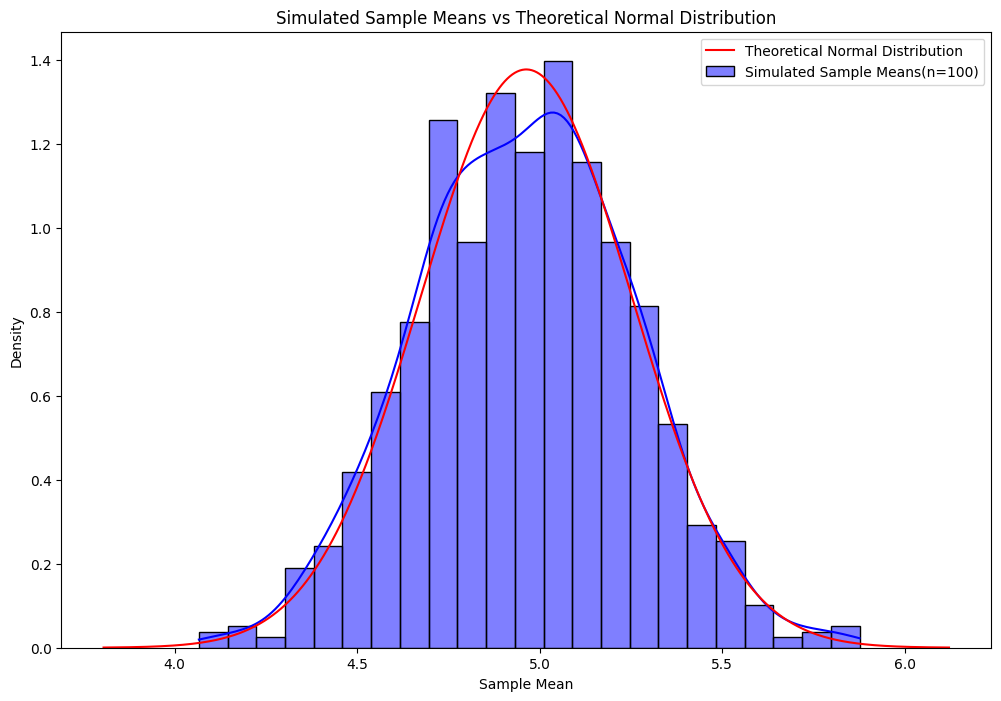

In [ ]:
import numpy as np
populationmean=np.mean(population)
populationstd=np.std(population)
samplesize=100
theoreticalstd=populationstd/np.sqrt(samplesize)
plt.figure(figsize=(12,8))
sns.histplot(samplemeans[100],kde=True,stat='density',color='blue',label='Simulated Sample Means(n=100)')
x=np.linspace(populationmean-4*theoreticalstd,populationmean+4*theoreticalstd,1000)
y=(1/(theoreticalstd*np.sqrt(2*np.pi)))*np.exp(-0.5*((x-populationmean)/theoreticalstd)**2)
plt.plot(x,y,color='red',label='Theoretical Normal Distribution')
plt.title("Simulated Sample Means vs Theoretical Normal Distribution")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()
plt.show()

plotting the discrete and continuous sample distribution

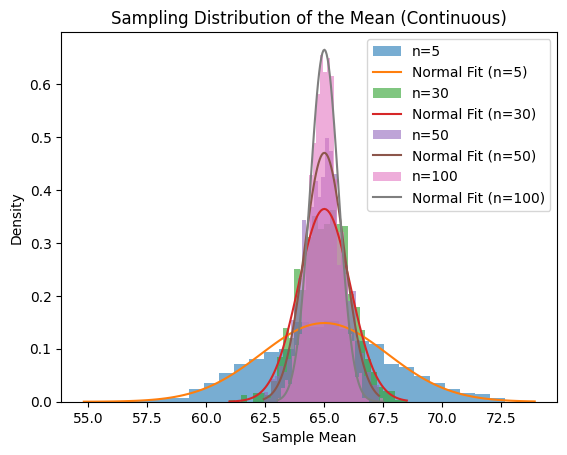

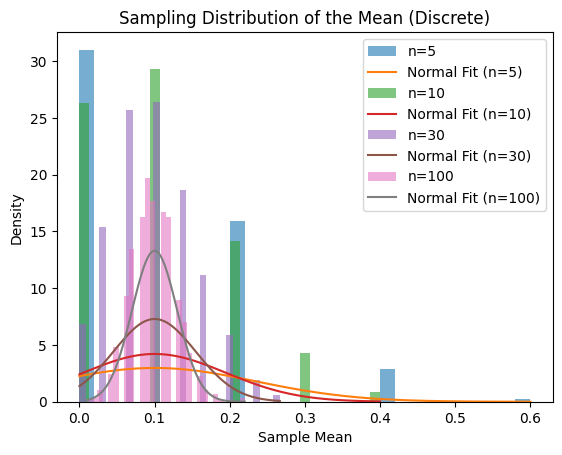

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

def cltcontinuous(populationmean, populationstd, populationsize, samplesizes, numsamples):
    population = np.random.normal(populationmean, populationstd, populationsize)

    for n in samplesizes:
        samplemeans = []

        for _ in range(numsamples):
            sample = np.random.choice(population, size=n, replace=True)
            samplemeans.append(np.mean(sample))

        plt.hist(samplemeans, bins=30, alpha=0.6, density=True, label=f'n={n}')

        samplingstd = populationstd / np.sqrt(n)
        x = np.linspace(min(samplemeans), max(samplemeans), 100)
        plt.plot(x, norm.pdf(x, populationmean, samplingstd), label=f'Normal Fit (n={n})')

    plt.title("Sampling Distribution of the Mean (Continuous)")
    plt.xlabel("Sample Mean")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


def cltdiscrete(prob, samplesizes, numsamples):
    population = np.random.choice([0, 1], p=[1 - prob, prob], size=100000)

    for n in samplesizes:
        samplemeans = []

        for _ in range(numsamples):
            sample = np.random.choice(population, size=n, replace=True)
            samplemeans.append(np.mean(sample))

        plt.hist(samplemeans, bins=30, alpha=0.6, density=True, label=f'n={n}')

        samplingstd = np.sqrt(prob * (1 - prob)) / np.sqrt(n)
        samplingmean = prob
        x = np.linspace(min(samplemeans), max(samplemeans), 100)
        plt.plot(x, norm.pdf(x, samplingmean, samplingstd), label=f'Normal Fit (n={n})')

    plt.title("Sampling Distribution of the Mean (Discrete)")
    plt.xlabel("Sample Mean")
    plt.ylabel("Density")
    plt.legend()
    plt.show()



populationmean = 65
populationstd = 6
populationsize = 1_000_000
samplesizes = [5, 30, 50, 100]
numsamples = 1000

cltcontinuous(populationmean, populationstd, populationsize, samplesizes, numsamples)

problefthanded = 0.1
samplesizes = [5, 10, 30, 100]
numsamples = 1000

cltdiscrete(problefthanded, samplesizes, numsamples)


plotting the sample distribution for uniform and sample distribution

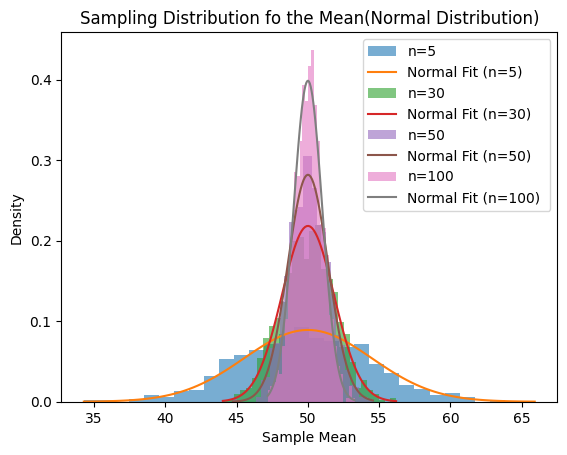

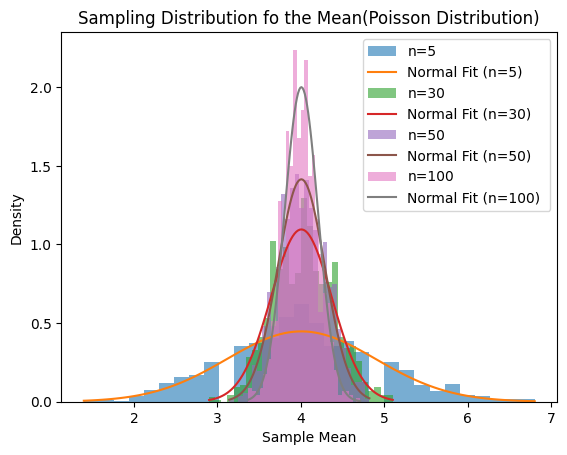

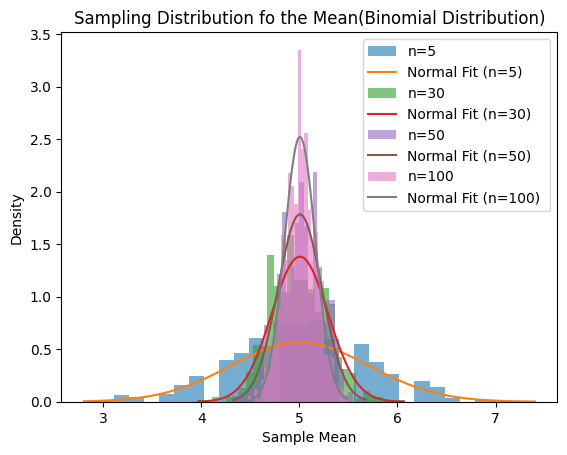

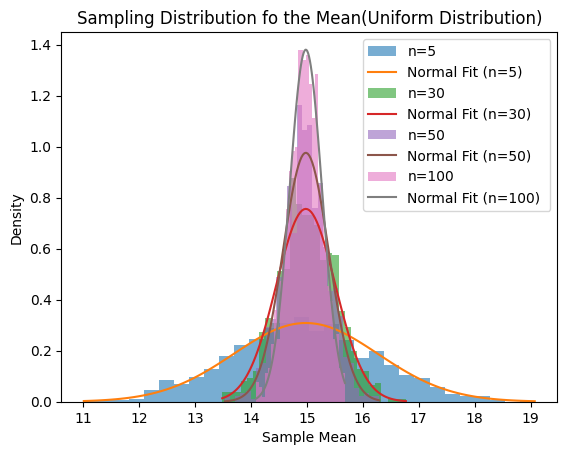

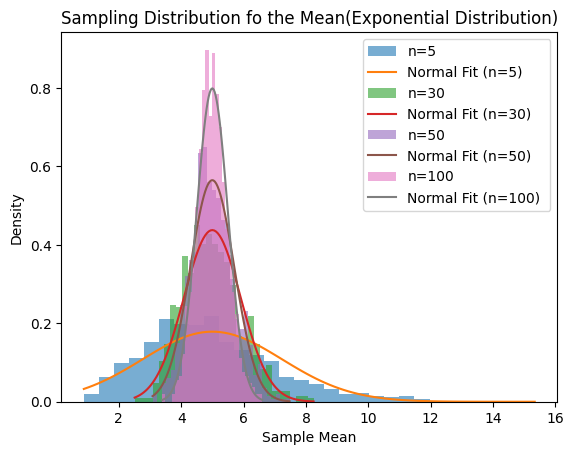

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm,poisson,binom
np.random.seed(42)
def cltsimulation(population,samplesizes,numsamples,distname):
  for n in samplesizes:
    samplemeans=[]
    for _ in range(numsamples):
      sample=np.random.choice(population,size=n,replace=False)
      samplemeans.append(np.mean(sample))
    plt.hist(samplemeans,bins=30,alpha=0.6,density=True,label=f'n={n}')
    samplingmean=np.mean(population)
    samplingstd=np.std(population)/np.sqrt(n)
    x=np.linspace(min(samplemeans),max(samplemeans),100)
    plt.plot(x,norm.pdf(x,samplingmean,samplingstd),label=f'Normal Fit (n={n}) ')
  plt.title(f'Sampling Distribution fo the Mean({distname})')
  plt.xlabel('Sample Mean')
  plt.ylabel('Density')
  plt.legend()
  plt.show()
populationnormal=np.random.normal(loc=50,scale=10,size=100000)
samplesizes=[5,30,50,100]
numsamples=1000
cltsimulation(populationnormal,samplesizes,numsamples,"Normal Distribution")
populationpoisson=np.random.poisson(lam=4,size=100000)
cltsimulation(populationpoisson,samplesizes,numsamples,"Poisson Distribution")
populationbinomial=np.random.binomial(n=10,p=0.5,size=100000)
cltsimulation(populationbinomial,samplesizes,numsamples,"Binomial Distribution")
populationuniform=np.random.uniform(low=10,high=20,size=100000)
cltsimulation(populationuniform,samplesizes,numsamples,"Uniform Distribution")
populationexponential=np.random.exponential(scale=5,size=100000)
cltsimulation(populationexponential,samplesizes,numsamples,"Exponential Distribution")


